[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MaxMitre/Mate_MercadosFinancieros/blob/main/Semana19_Criptografia_PoW.ipynb)

In [ ]:
import numpy as np

# Cifrado de datos con matriz: Ejemplo utilizando el método

In [ ]:
def mod_inverse(matrix, mod):
    """Encuentra el inverso modular de una matriz en módulo `mod`."""
    determinant = int(round(np.linalg.det(matrix)))
    determinant_inv = pow(determinant, -1, mod)  # Inverso modular del determinante
    matrix_mod_inv = (
        determinant_inv * np.round(determinant * np.linalg.inv(matrix)).astype(int) % mod
    )
    return matrix_mod_inv

In [ ]:
def text_to_numbers(text):
    """Convierte un texto en una lista de números (A=0, B=1, ..., Z=25)."""
    return [ord(char) - ord('A') for char in text.upper() if char.isalpha()]

In [ ]:
def numbers_to_text(numbers):
    """Convierte una lista de números en texto (0=A, 1=B, ..., 25=Z)."""
    return ''.join(chr(num + ord('A')) for num in numbers)

In [ ]:
def encrypt(message, key):
    """Cifra un mensaje utilizando el método Hill Cipher."""
    message_numbers = text_to_numbers(message)

    # Ajustar el mensaje para que sea divisible por el tamaño de la matriz clave
    while len(message_numbers) % key.shape[0] != 0:
        message_numbers.append(0)  # Añadir 'A' (valor 0)

    # Convertir a una matriz para operaciones con la clave
    message_matrix = np.array(message_numbers).reshape(-1, key.shape[0])

    # Cifrar: Multiplicar por la matriz clave y aplicar módulo 26
    encrypted_matrix = (message_matrix @ key) % 26

    # Convertir de números a texto
    encrypted_numbers = encrypted_matrix.flatten()
    return numbers_to_text(encrypted_numbers)

In [ ]:
def decrypt(ciphertext, key):
    """Descifra un mensaje utilizando el método Hill Cipher."""
    ciphertext_numbers = text_to_numbers(ciphertext)

    # Convertir a una matriz para operaciones con la clave
    ciphertext_matrix = np.array(ciphertext_numbers).reshape(-1, key.shape[0])

    # Calcular el inverso de la clave
    key_inverse = mod_inverse(key, 26)

    # Descifrar: Multiplicar por el inverso de la matriz clave y aplicar módulo 26
    decrypted_matrix = (ciphertext_matrix @ key_inverse) % 26

    # Convertir de números a texto
    decrypted_numbers = decrypted_matrix.flatten()
    return numbers_to_text(decrypted_numbers)

In [ ]:
# Matriz clave (debe ser cuadrada y tener un determinante invertible en módulo 26)
key = np.array([
    [6, 24, 1],
    [13, 16, 10],
    [20, 17, 15]
])

# Mensaje a cifrar
message = "HELLO"

# Cifrado
print("Mensaje original:", message)
ciphertext = encrypt(message, key)
print("Mensaje cifrado:", ciphertext)

# Descifrado
decrypted_message = decrypt(ciphertext, key)
print("Mensaje descifrado:", decrypted_message)


Mensaje original: HELLO
Mensaje cifrado: CDEOUV
Mensaje descifrado: HELLOA


# Como funciona una curva elíptica: rápido vistazo

Todo recae en la operación modular:
$kG = P$


# Ejemplo de operaciones en el campo finito \( $\mathbb{F}_{11} $ \)

En el campo finito, trabajamos con los números $( \{0, 1, 2, \dots, 10\} )$ y todas las operaciones se realizan $\textbf{mod 11}$. A continuación, realizaremos una serie de operaciones comunes: suma, multiplicación y división.

## Operación de suma:

Queremos sumar dos elementos en $\mathbb{F}_{11}$. Por ejemplo, sumar $7$  y  $5$ :


$7 + 5 = 12$

Ahora, tomamos el resultado módulo 11:

$12 \mod 11 = 1$

Por lo tanto, $7 + 5 \equiv 1 \pmod{11} $.

## Operación de multiplicación:

Ahora vamos a multiplicar $3 $ y $4$ en $\mathbb{F}_{11}$:

$3 \times 4 = 12$

Tomamos el resultado módulo 11:


$12 \mod 11 = 1$

Así que $3 \times 4 \equiv 1 \pmod{11}$.

## Operación de división:

La división en un campo finito implica multiplicar por el $\textbf{inverso multiplicativo}$. Supongamos que queremos dividir $9$ entre $3$ en $\mathbb{F}_{11}$. Es decir, necesitamos encontrar el número $x$ tal que:

$3 \times x \equiv 9 \pmod{11}$

Para resolver esto, encontramos el $\textbf{inverso multiplicativo de 3}$ en $\mathbb{F}_{11}$. Esto significa encontrar un número $y$ tal que:

$3 \times y \equiv 1 \pmod{11}$

Probamos los valores de $y$ para ver cuál satisface esta ecuación:

\begin{aligned}
3 \times 1 &= 3 \\
3 \times 2 &= 6 \\
3 \times 3 &= 9 \\
3 \times 4 &= 12 \equiv 1 \pmod{11}
\end{aligned}


Así que $ 3^{-1} \equiv 4 \pmod{11} $.

Ahora multiplicamos $9$ por el inverso de $3$:

$9 \times 4 = 36$

Tomamos el resultado módulo 11:

$36 \mod 11 = 3$

Entonces, $9 \div 3 \equiv 3 \pmod{11}$.

## Resumen de opreaciones:
  - $7 + 5 \equiv 1 \pmod{11}$
  - $3 \times 4 \equiv 1 \pmod{11}$
  - $9 \div 3 \equiv 3 \pmod{11}$





$$ y^2 = x^3 + x + 6 \,\,\, mod \,\,\, 11$$

sustituyendo $(2,4)$:

lado izq:
$4*4 \,\, mod\,\, 11 = 5$

lado derecho:
$2*2*2+2+6 = 16 \,\, mod 11 = 5$

In [ ]:
74%11

8

In [ ]:
def is_quadratic_residue(n, p):
    """Comprueba si n es un residuo cuadrático en el campo finito Fp."""
    return pow(n, (p - 1) // 2, p) == 1

def find_points_on_curve(a, b, p):
    """Encuentra todos los puntos (x, y) que satisfacen la curva elíptica y^2 = x^3 + ax + b (mod p)."""
    points = []
    for x in range(p):
        rhs = (x**3 + a * x + b) % p  # Calcula el lado derecho de la ecuación
        for y in range(p):
            if (y**2) % p == rhs:  # Verifica si y^2 ≡ rhs (mod p)
                points.append((x, y))
    return points

# Definir la curva elíptica: y^2 = x^3 + ax + b (mod p)
a = 1
b = 6
p = 11  # Campo finito F11

# Encontrar puntos
points = find_points_on_curve(a, b, p)

# Mostrar los puntos
print(f"Curva: y^2 = x^3 + {a}x + {b} (mod {p})")
print("Puntos en la curva:")
for point in points:
    print(point)

# Número total de puntos
print(f"Número total de puntos: {len(points)}")

Curva: y^2 = x^3 + 1x + 6 (mod 11)
Puntos en la curva:
(2, 4)
(2, 7)
(3, 5)
(3, 6)
(5, 2)
(5, 9)
(7, 2)
(7, 9)
(8, 3)
(8, 8)
(10, 2)
(10, 9)
Número total de puntos: 12


In [ ]:
def point_addition(P, Q, a, p):
    """Suma dos puntos P y Q en la curva elíptica sobre el campo finito Fp."""
    if P == Q:  # Caso de doblado de un punto
        if P[1] == 0:  # Si y == 0, el doblado es el punto en el infinito
            return None
        m = (3 * P[0]**2 + a) * pow(2 * P[1], -1, p) % p
    else:  # Caso de suma de puntos distintos
        if P[0] == Q[0]:  # Si x1 == x2, el resultado es el punto en el infinito
            return None
        m = (Q[1] - P[1]) * pow(Q[0] - P[0], -1, p) % p

    x_r = (m**2 - P[0] - Q[0]) % p
    y_r = (m * (P[0] - x_r) - P[1]) % p
    return (x_r, y_r)

def scalar_multiply(k, P, a, p):
    """Realiza la multiplicación escalar k*P."""
    result = None  # Punto en el infinito
    temp = P
    for i in range(k):
        if result is None:
            result = temp
        else:
            result = point_addition(result, P, a, p)
    return result

# Parámetros de la curva
a = 1
b = 6
p = 11
G = (2, 4)  # Punto inicial

# Iterar y encontrar múltiplos del punto
print(f"Punto base: {G}")
puntos = []*15
for k in range(1, 15):  # Iterar desde 1P hasta 14P
    result = scalar_multiply(k, G, a, p)
    print(f"{k} * P = {result}")
    puntos.append(result)


Punto base: (2, 4)
1 * P = (2, 4)
2 * P = (5, 9)
3 * P = (8, 8)
4 * P = (10, 9)
5 * P = (3, 5)
6 * P = (7, 2)
7 * P = (7, 9)
8 * P = (3, 6)
9 * P = (10, 2)
10 * P = (8, 3)
11 * P = (5, 2)
12 * P = (2, 7)
13 * P = None
14 * P = (2, 4)


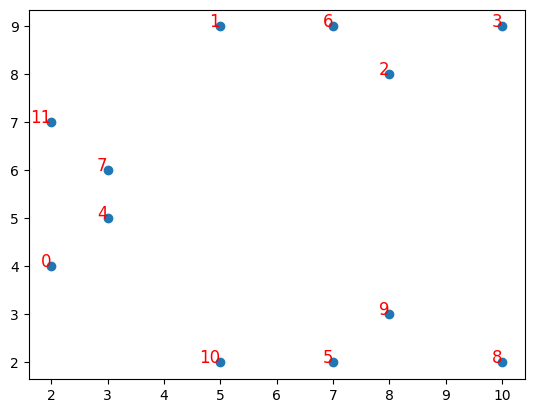

In [ ]:
import matplotlib.pyplot as plt
x, y = zip(*puntos[:12])

# Create the scatter plot
plt.scatter(x, y)
for i, (xi, yi) in enumerate(zip(x, y)):
  if i < 20:
    plt.text(xi, yi, str(i), fontsize=12, ha='right', color='red')  # Add the index near each point


$k(2,4) = P$

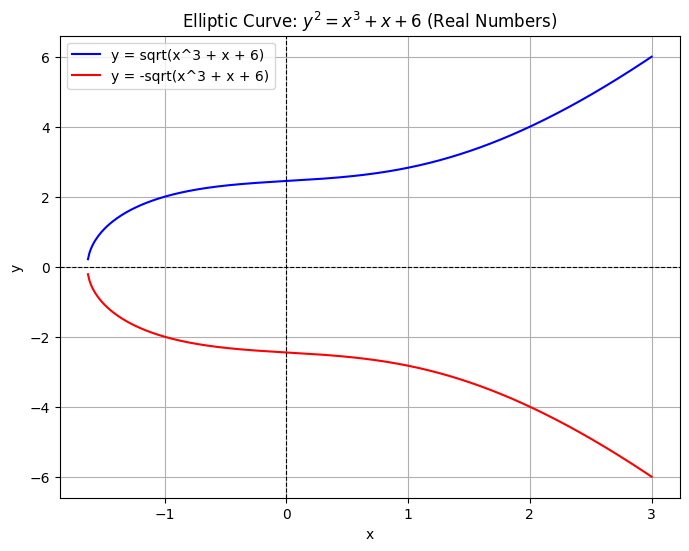

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the elliptic curve: y^2 = x^3 + x + 6
def elliptic_curve(x, a, b):
    return x**3 + a*x + b

# Curve parameters
a = 1
b = 6

# Define x values in a continuous range
x = np.linspace(-3, 3, 500)  # Range of x over the reals

# Calculate y^2 for the curve
y2 = elliptic_curve(x, a, b)

# Filter valid values where y^2 >= 0 (to keep real numbers)
valid_indices = y2 >= 0
x_valid = x[valid_indices]
y2_valid = y2[valid_indices]

# Calculate y as the square root of y^2 (two branches of the curve)
y_positive = np.sqrt(y2_valid)
y_negative = -np.sqrt(y2_valid)

# Plot the curve
plt.figure(figsize=(8, 6))
plt.plot(x_valid, y_positive, label="y = sqrt(x^3 + x + 6)", color="blue")
plt.plot(x_valid, y_negative, label="y = -sqrt(x^3 + x + 6)", color="red")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Elliptic Curve: $y^2 = x^3 + x + 6$ (Real Numbers)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()


# Signature Algorithm

In [ ]:
from random import randint

# Parámetros de la curva elíptica
p = 11  # Campo finito
a, b = 1, 6  # Coeficientes de la curva
G = (2, 4)  # Punto base

# Función para sumar puntos en la curva
def point_addition(P, Q):
    if P == Q:  # Doble de un punto
        m = (3 * P[0]**2 + a) * pow(2 * P[1], -1, p) % p
    else:  # Suma de puntos diferentes
        m = (Q[1] - P[1]) * pow(Q[0] - P[0], -1, p) % p
    x_r = (m**2 - P[0] - Q[0]) % p
    y_r = (m * (P[0] - x_r) - P[1]) % p
    return (x_r, y_r)

# Función para realizar la negación de un punto
def point_negation(P):
    return (P[0], (-P[1]) % p)

# Multiplicación escalar
def scalar_multiply(d, G):
    result = None  # Punto en el infinito
    temp = G
    while d > 0:
        if d % 2 == 1:
            result = point_addition(result, temp) if result else temp
        temp = point_addition(temp, temp)
        d //= 2
    return result

# Generación de claves
d = randint(1, p - 1)  # Clave privada
Q = scalar_multiply(d, G)  # Clave pública

# Firma digital
def sign_message(message, d):
    k = randint(1, p - 1)  # Número aleatorio
    R = scalar_multiply(k, G)  # R = kG
    x_R = R[0]  # Coordenada x de R
    s = ((message + d * x_R) * pow(k, -1, p)) % p  # s = (m + dx_R) / k mod p
    return (x_R, s)

# Verificar la firma
def verify_signature(message, signature, Q):
    x_R, s = signature
    R_calc = point_addition(
        scalar_multiply((message * pow(s, -1, p)) % p, G),
        scalar_multiply((x_R * pow(s, -1, p)) % p, Q)
    )
    return R_calc[0] == x_R

# Ejemplo de uso
message = 7  # Mensaje a firmar (representado como número)
signature = sign_message(message, d)  # Firma el mensaje
is_valid = verify_signature(message, signature, Q)  # Verifica la firma

# Imprimir resultados
print(f"Clave privada (d): {d}")
print(f"Clave pública (Q): {Q}")
print(f"Mensaje: {message}")
print(f"Firma: {signature}")
print(f"¿Firma válida?: {is_valid}")


Clave privada (d): 9
Clave pública (Q): (10, 2)
Mensaje: 7
Firma: (7, 8)
¿Firma válida?: False


Explicación:

Generación de claves:
- La clave privada es un numero aleatorio $d$
- La clave pública es $Q = dG$, donde $G$ es un punto base

Firma del Mensaje:
- Se elige un número aleatorio $k$ y se calcula $R = kG$
- La coordenada $x_R$ de $R$ se utiliza en el cálculo de $s$:
$$ s = \dfrac{m + d\cdot x_R}{k}  \,\,\,\, \mbox{mod} \,\, p $$
- La firma es el par $(x_R, s)$

Verificación:
- El verificador calcula:
$$ R^{\prime} = (\dfrac{m}{s} \, mod \, p \, \cdot G) + (\dfrac{x_R}{s} \, mod \, p \, \cdot Q) $$

- Si la coordenada $x^{\prime}_R$ de $R^{\prime}$ coincide  con $x_R$ de la firma, entonces la firma es válida

¿Porque funciona?

Solo quien conoce la clave privada $d$ puede generar una firma válida

Cualquiera con la clave pública $Q$ puede verificar si esto es cierto

# Dato curioso:

Para bitcoin, los parámetros de la curva son:
- $a = 0$, $b=7$, por lo que la ecuación es $y^2 = x^3 + 7$
- $p = 2^{256} - 2^{32} - 977$

Demás valores en el capítulo 3 del libro de referencias.

El nombre que recibe esta curva es **secp256k1**

# Proof of Work

Simulador: https://blockchain-academy.hs-mittweida.de/2021/05/proof-of-work-simulator/

In [ ]:
import hashlib
import time

# Clase para representar un bloque
class Block:
    def __init__(self, index, previous_hash, data, timestamp=None):
        self.index = index
        self.previous_hash = previous_hash
        self.data = data
        self.timestamp = timestamp or time.time()
        self.nonce = 0
        self.hash = self.calculate_hash()

    # Calcular el hash del bloque
    def calculate_hash(self):
        block_string = f"{self.index}{self.previous_hash}{self.data}{self.timestamp}{self.nonce}"
        return hashlib.sha256(block_string.encode()).hexdigest()

    # Prueba de trabajo para encontrar un hash válido
    def mine_block(self, difficulty):
        target = "0" * difficulty
        while not self.hash.startswith(target):
            self.nonce += 1
            self.hash = self.calculate_hash()
        print(f"Block mined: {self.hash}")

# Crear el bloque génesis
print("Creating genesis block...")
genesis_block = Block(index=0, previous_hash="0", data="Genesis Block")
difficulty = 6  # Nivel de dificultad: número de ceros iniciales requeridos

genesis_block.mine_block(difficulty)

# Crear un segundo bloque
print("\nCreating second block...")
second_block = Block(index=1, previous_hash=genesis_block.hash, data="Second Block")
second_block.mine_block(difficulty)

# Validar un bloque
print("\nValidating blocks...")
def validate_block(block, previous_block):
    if block.previous_hash != previous_block.hash:
        return False
    if block.hash != block.calculate_hash():
        return False
    if not block.hash.startswith("0" * difficulty):
        return False
    return True

is_valid = validate_block(second_block, genesis_block)
print(f"Is the second block valid? {is_valid}")


Creating genesis block...
Block mined: 0000000d7dbe20ab9b476636fa5cde642d119a7a8cb2830e1d15e64cd1995488

Creating second block...
Block mined: 000000dfccfadd4f8a78da50b372cccfe44f8597341b50d6b68d9dc73e759c11

Validating blocks...
Is the second block valid? True


# Explicación:

## **Método calculate_hash**

Genera un hash único basado en el contenido del bloque. Esto asegura la integridad de los datos.

- Combina los atributos del bloque (index, previous_hash, data, timestamp, nonce) en una cadena.
- Usa SHA-256 para calcular un hash único.
- Cada cambio en el contenido genera un hash completamente diferente.

## **Método mine_block**

Resuelve la prueba de trabajo (PoW) al encontrar un hash que comience con un número específico de ceros.

- difficulty determina cuántos ceros iniciales debe tener el hash.
- Incrementa el nonce hasta que el hash cumpla con el objetivo.
- Al cumplirlo, el bloque está "minado".

## Validar un bloque:

- Comprueba que el hash del bloque anterior coincide con previous_hash.
- Recalcula el hash para validar que no se haya alterado.
- Verifica que el hash cumpla con la dificultad.

# Ejercicio:

Escriba un texto, cífrelo y obtenga el hash de dicho mensaje. Despues, altere el mensaje en un solo caracter y observe el hash de ese nuevo mensaje. ¿Qué se puede apreciar?

¿Cómo se relaciona esto con los puntos que pintamos para la curva elíptica sencilla?

# Referencias:

[Programing Bitcoin: Learn How to Program Bitcoin from Scratch: Chapter 3](https://www.amazon.com/-/es/Programming-Bitcoin-Learn-Program-Scratch/dp/1492031496)
